In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

from src.models.clustering import CustomerClustering, add_cluster_labels

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

np.random.seed(42)


In [2]:
customer_features = pd.read_csv('../data/processed/customer_features.csv')

print(f"Loaded {len(customer_features):,} customers")
print(f"Columns: {list(customer_features.columns)}")

customer_features.head()

Loaded 4,312 customers
Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Total', 'Total_Items', 'Total_Orders', 'Avg_Order_Value', 'Unique_Products', 'First_Purchase', 'Last_Purchase', 'Avg_Items_Per_Order', 'Customer_Lifespan_Days', 'Purchase_Frequency', 'Segment_Preview']


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Total_Items,Total_Orders,Avg_Order_Value,Unique_Products,First_Purchase,Last_Purchase,Avg_Items_Per_Order,Customer_Lifespan_Days,Purchase_Frequency,Segment_Preview
0,12346.00,165,11,372.86,2,5,2,252,9,70,11,11.30,26,2009-12-14 08:34:00,2010-06-28 13:53:00,6.36,196,0.06,Medium Value
1,12347.00,3,2,1323.32,5,2,4,524,11,828,2,18.64,70,2010-10-31 14:20:00,2010-12-07 14:57:00,414.00,37,0.05,High Value
2,12348.00,74,1,222.16,2,1,1,211,4,373,1,11.11,20,2010-09-27 14:59:00,2010-09-27 14:59:00,373.00,0,1.00,Low Value
3,12349.00,43,3,2671.14,3,3,5,335,11,993,3,26.19,90,2010-04-29 13:20:00,2010-10-28 08:23:00,331.00,181,0.02,High Value
4,12351.00,11,1,300.93,5,1,2,512,8,261,1,14.33,21,2010-11-29 15:23:00,2010-11-29 15:23:00,261.00,0,1.00,Medium Value


In [3]:
feature_cols = ['Recency', 'Frequency', 'Monetary']

clustering = CustomerClustering(random_state=42)
X_scaled = clustering.prepare_features(customer_features, feature_cols)

print(f"Features prepared and scaled: {X_scaled.shape}")
print(f"Clustering features: {feature_cols}")
print(f"\nScaled data sample:")
print(pd.DataFrame(X_scaled, columns=feature_cols).head())
print(f"\nScaled means (should be ~0): {X_scaled.mean(axis=0).round(3)}")
print(f"Scaled stds  (should be ~1): {X_scaled.std(axis=0).round(3)}")

Features prepared and scaled: (4312, 3)
Clustering features: ['Recency', 'Frequency', 'Monetary']

Scaled data sample:
   Recency  Frequency  Monetary
0     0.76       0.80     -0.19
1    -0.91      -0.30     -0.08
2    -0.18      -0.42     -0.20
3    -0.50      -0.18      0.07
4    -0.83      -0.42     -0.20

Scaled means (should be ~0): [0. 0. 0.]
Scaled stds  (should be ~1): [1. 1. 1.]


In [4]:
k_range = range(2, 11)
metrics_df = clustering.find_optimal_k(X_scaled, k_range=k_range)

print("Cluster evaluation metrics:\n")
metrics_df

Cluster evaluation metrics:



,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,8728.91,0.93,2077.30,0.58
1,3,5160.29,0.59,3246.49,0.60
2,4,3587.35,0.61,3742.22,0.62
3,5,2740.12,0.61,4006.55,0.63
4,6,2236.06,0.51,4121.11,0.70
5,7,1820.11,0.49,4381.98,0.68
6,8,1560.10,0.49,4483.42,0.73
7,9,1401.95,0.41,4425.27,0.68
8,10,1251.15,0.42,4464.24,0.69


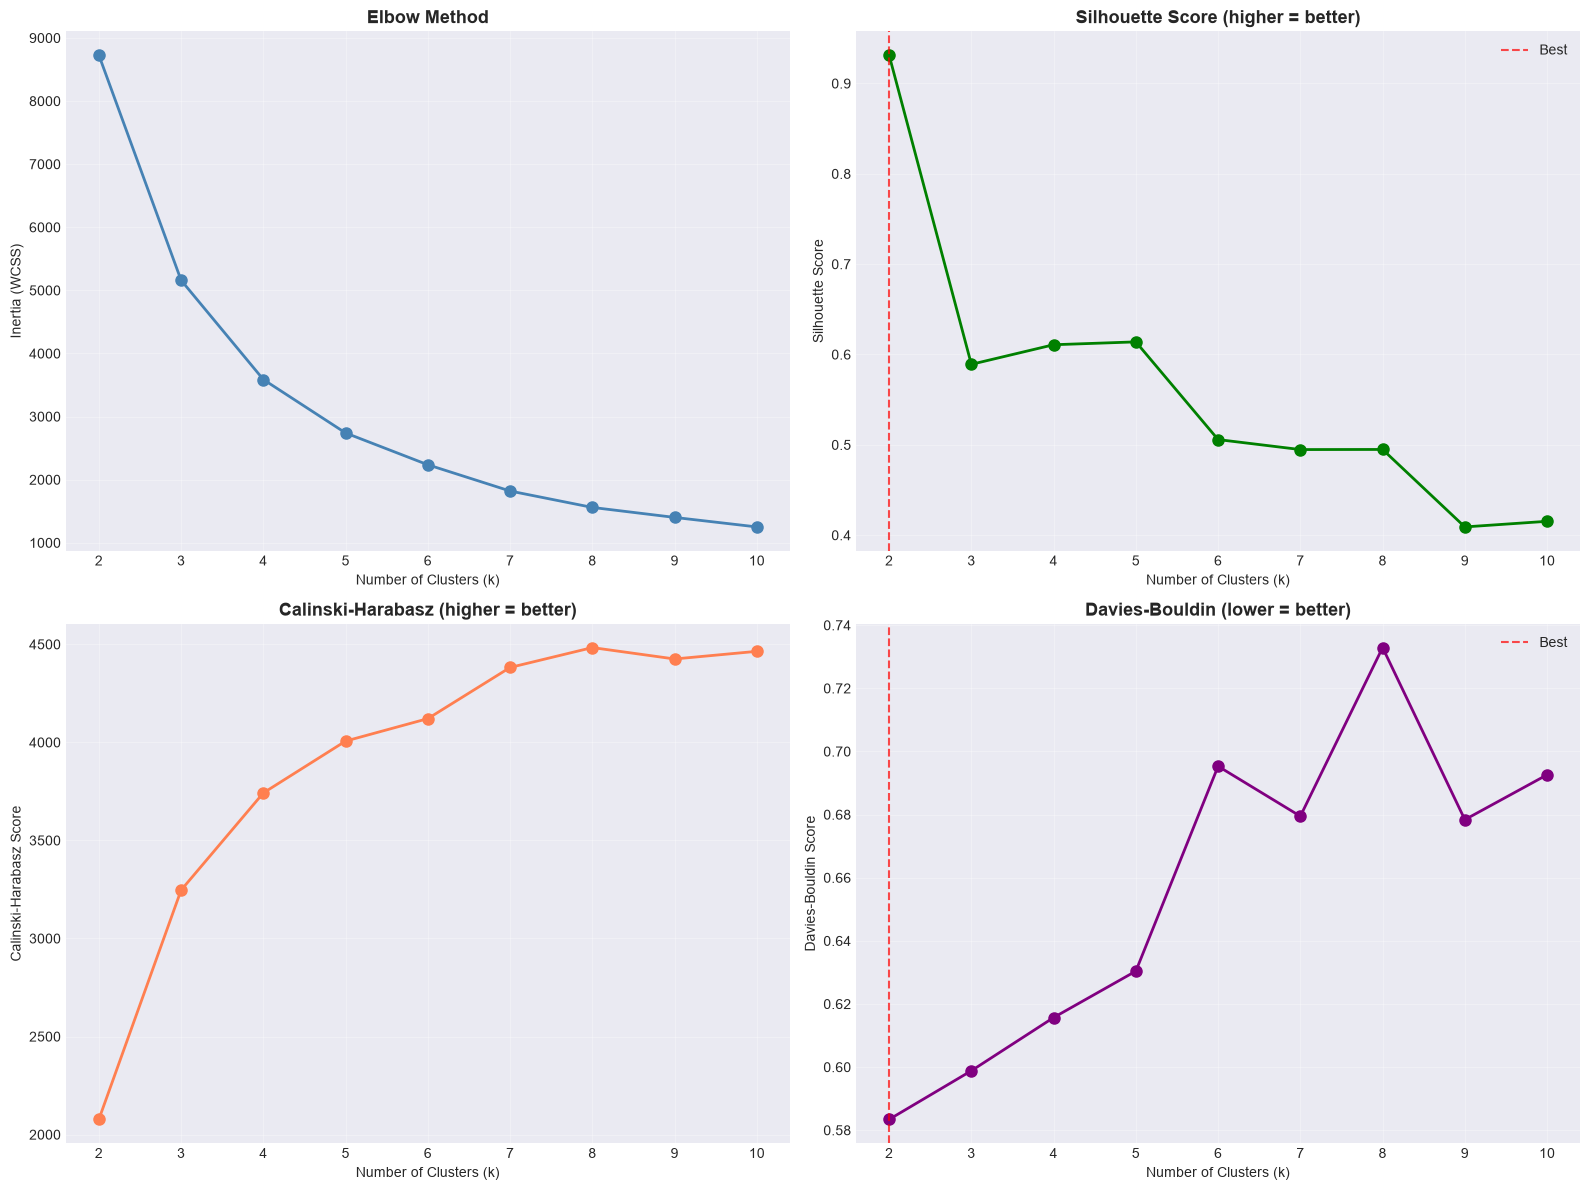

In [5]:

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Elbow (Inertia)
axes[0, 0].plot(metrics_df['k'], metrics_df['inertia'], 
                marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0, 0].set_xlabel('Number of Clusters (k)')
axes[0, 0].set_ylabel('Inertia (WCSS)')
axes[0, 0].set_title('Elbow Method', fontweight='bold', fontsize=13)
axes[0, 0].grid(alpha=0.3)

# Silhouette (higher = better)
axes[0, 1].plot(metrics_df['k'], metrics_df['silhouette'], 
                marker='o', linewidth=2, markersize=8, color='green')
axes[0, 1].set_xlabel('Number of Clusters (k)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].set_title('Silhouette Score (higher = better)', fontweight='bold', fontsize=13)
axes[0, 1].axvline(metrics_df.loc[metrics_df['silhouette'].idxmax(), 'k'],
                   color='red', linestyle='--', alpha=0.7, label='Best')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Calinski-Harabasz (higher = better)
axes[1, 0].plot(metrics_df['k'], metrics_df['calinski_harabasz'], 
                marker='o', linewidth=2, markersize=8, color='coral')
axes[1, 0].set_xlabel('Number of Clusters (k)')
axes[1, 0].set_ylabel('Calinski-Harabasz Score')
axes[1, 0].set_title('Calinski-Harabasz (higher = better)', fontweight='bold', fontsize=13)
axes[1, 0].grid(alpha=0.3)

# Davies-Bouldin (lower = better)
axes[1, 1].plot(metrics_df['k'], metrics_df['davies_bouldin'], 
                marker='o', linewidth=2, markersize=8, color='purple')
axes[1, 1].set_xlabel('Number of Clusters (k)')
axes[1, 1].set_ylabel('Davies-Bouldin Score')
axes[1, 1].set_title('Davies-Bouldin (lower = better)', fontweight='bold', fontsize=13)
axes[1, 1].axvline(metrics_df.loc[metrics_df['davies_bouldin'].idxmin(), 'k'],
                   color='red', linestyle='--', alpha=0.7, label='Best')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/kmeans_optimal_k.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:

best_silhouette_k = int(metrics_df.loc[metrics_df['silhouette'].idxmax(), 'k'])
best_ch_k = int(metrics_df.loc[metrics_df['calinski_harabasz'].idxmax(), 'k'])
best_db_k = int(metrics_df.loc[metrics_df['davies_bouldin'].idxmin(), 'k'])

print("Optimal k recommendations by metric:\n")
print(f"  Silhouette Score (max):        k = {best_silhouette_k}")
print(f"  Calinski-Harabasz (max):       k = {best_ch_k}")
print(f"  Davies-Bouldin (min):          k = {best_db_k}")

print(f"\nNote: The elbow method is visual - inspect the plot above.")
print(f"For business interpretability, k=4 often balances")
print(f"statistical quality with actionable segments.")

Optimal k recommendations by metric:

  Silhouette Score (max):        k = 2
  Calinski-Harabasz (max):       k = 8
  Davies-Bouldin (min):          k = 2

Note: The elbow method is visual - inspect the plot above.
For business interpretability, k=4 often balances
statistical quality with actionable segments.


In [7]:
OPTIMAL_K = 4

model = clustering.fit(X_scaled, n_clusters=OPTIMAL_K)
labels = clustering.predict(X_scaled)

print(f"K-Means fitted with k={OPTIMAL_K}")
print(f"Cluster sizes:")
print(pd.Series(labels).value_counts().sort_index())

eval_metrics = clustering.evaluate(X_scaled, labels)
print(f"\nFinal model metrics:")
for metric, value in eval_metrics.items():
    print(f"  {metric}: {value:.3f}")
    

K-Means fitted with k=4
Cluster sizes:
0    3204
1    1047
2       5
3      56
Name: count, dtype: int64

Final model metrics:
  silhouette: 0.611
  calinski_harabasz: 3742.219
  davies_bouldin: 0.616
  inertia: 3587.352


In [8]:
customer_clustered = add_cluster_labels(customer_features, labels, col_name='Cluster')

print("Cluster label distribution:\n")
cluster_dist = customer_clustered['Cluster'].value_counts().sort_index()
for cluster, count in cluster_dist.items():
    pct = (count / len(customer_clustered)) * 100
    print(f"  Cluster {cluster}: {count:,} customers ({pct:.1f}%)")

customer_clustered.head()

Cluster label distribution:

  Cluster 0: 3,204 customers (74.3%)
  Cluster 1: 1,047 customers (24.3%)
  Cluster 2: 5 customers (0.1%)
  Cluster 3: 56 customers (1.3%)


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Total_Items,Total_Orders,Avg_Order_Value,Unique_Products,First_Purchase,Last_Purchase,Avg_Items_Per_Order,Customer_Lifespan_Days,Purchase_Frequency,Segment_Preview,Cluster
0,12346.00,165,11,372.86,2,5,2,252,9,70,11,11.30,26,2009-12-14 08:34:00,2010-06-28 13:53:00,6.36,196,0.06,Medium Value,1
1,12347.00,3,2,1323.32,5,2,4,524,11,828,2,18.64,70,2010-10-31 14:20:00,2010-12-07 14:57:00,414.00,37,0.05,High Value,0
2,12348.00,74,1,222.16,2,1,1,211,4,373,1,11.11,20,2010-09-27 14:59:00,2010-09-27 14:59:00,373.00,0,1.00,Low Value,0
3,12349.00,43,3,2671.14,3,3,5,335,11,993,3,26.19,90,2010-04-29 13:20:00,2010-10-28 08:23:00,331.00,181,0.02,High Value,0
4,12351.00,11,1,300.93,5,1,2,512,8,261,1,14.33,21,2010-11-29 15:23:00,2010-11-29 15:23:00,261.00,0,1.00,Medium Value,0


In [9]:
centers = clustering.get_cluster_centers()

print("Cluster Centers (original scale):\n")
centers.round(2)

Cluster Centers (original scale):



,Recency,Frequency,Monetary
Cluster,,,
0,43.03,4.46,1710.65
1,242.98,1.66,593.54
2,5.60,113.60,215535.00
3,14.91,47.02,28896.42


In [10]:
cluster_profile = customer_clustered.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'sum'],
    'Customer ID': 'count'
}).round(2)

cluster_profile.columns = ['Avg_Recency', 'Avg_Frequency', 
                           'Avg_Monetary', 'Total_Revenue', 'Count']

# Share of total revenue
total_rev = cluster_profile['Total_Revenue'].sum()
cluster_profile['Revenue_Share_%'] = (
    cluster_profile['Total_Revenue'] / total_rev * 100
).round(1)

print("Cluster Profiles:\n")
cluster_profile

Cluster Profiles:



,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Count,Revenue_Share_%
Cluster,,,,,,
0,43.03,4.46,1710.65,5480922.70,3204,62.30
1,242.98,1.66,593.54,621436.71,1047,7.10
2,5.60,113.60,215535.00,1077675.00,5,12.20
3,14.91,47.02,28896.42,1618199.33,56,18.40


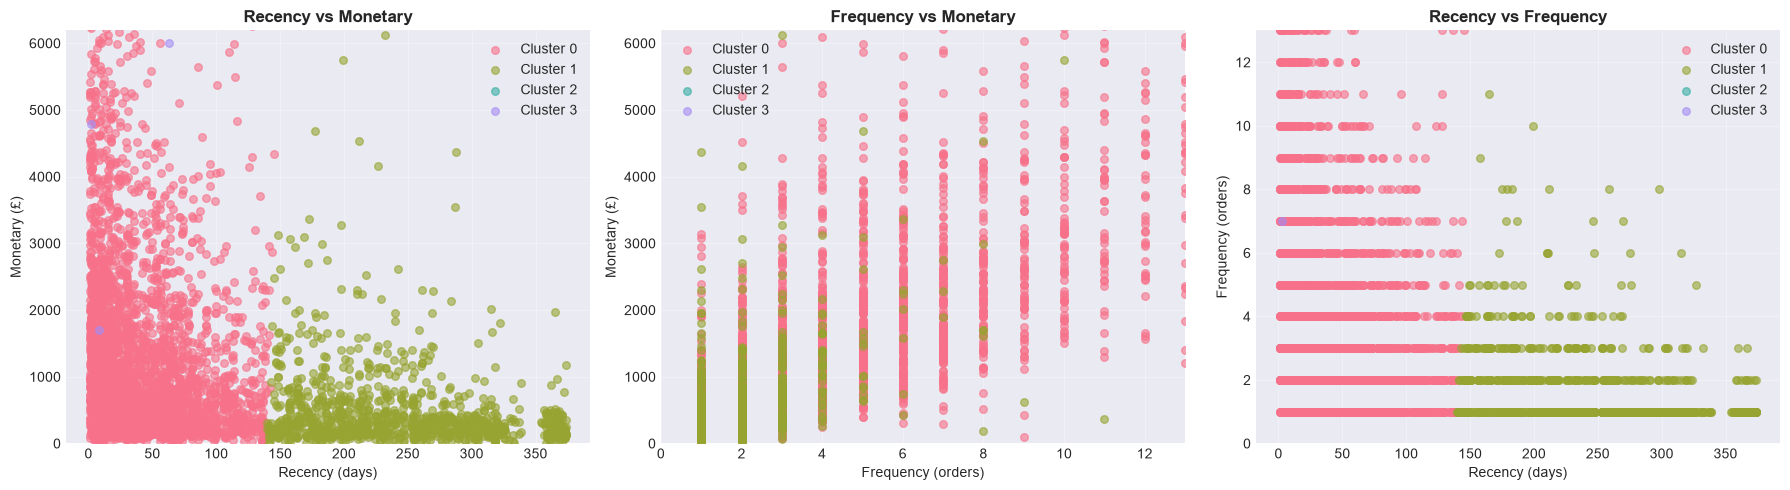

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

palette = sns.color_palette("husl", OPTIMAL_K)

# Recency vs Monetary
for c in range(OPTIMAL_K):
    mask = customer_clustered['Cluster'] == c
    axes[0].scatter(customer_clustered.loc[mask, 'Recency'],
                    customer_clustered.loc[mask, 'Monetary'],
                    label=f'Cluster {c}', alpha=0.6, s=30, color=palette[c])
axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Monetary (£)')
axes[0].set_title('Recency vs Monetary', fontweight='bold')
axes[0].set_ylim(0, customer_clustered['Monetary'].quantile(0.95))
axes[0].legend()
axes[0].grid(alpha=0.3)

# Frequency vs Monetary
for c in range(OPTIMAL_K):
    mask = customer_clustered['Cluster'] == c
    axes[1].scatter(customer_clustered.loc[mask, 'Frequency'],
                    customer_clustered.loc[mask, 'Monetary'],
                    label=f'Cluster {c}', alpha=0.6, s=30, color=palette[c])
axes[1].set_xlabel('Frequency (orders)')
axes[1].set_ylabel('Monetary (£)')
axes[1].set_title('Frequency vs Monetary', fontweight='bold')
axes[1].set_xlim(0, customer_clustered['Frequency'].quantile(0.95))
axes[1].set_ylim(0, customer_clustered['Monetary'].quantile(0.95))
axes[1].legend()
axes[1].grid(alpha=0.3)

# Recency vs Frequency
for c in range(OPTIMAL_K):
    mask = customer_clustered['Cluster'] == c
    axes[2].scatter(customer_clustered.loc[mask, 'Recency'],
                    customer_clustered.loc[mask, 'Frequency'],
                    label=f'Cluster {c}', alpha=0.6, s=30, color=palette[c])
axes[2].set_xlabel('Recency (days)')
axes[2].set_ylabel('Frequency (orders)')
axes[2].set_title('Recency vs Frequency', fontweight='bold')
axes[2].set_ylim(0, customer_clustered['Frequency'].quantile(0.95))
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/kmeans_cluster_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

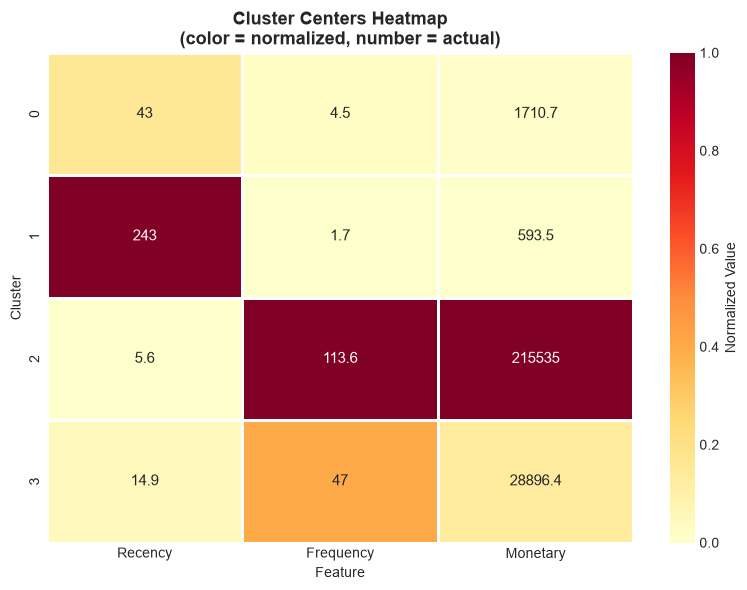

In [12]:
centers_normalized = (centers - centers.min()) / (centers.max() - centers.min())

plt.figure(figsize=(8, 6))
sns.heatmap(centers_normalized, annot=centers.round(1), fmt='g',
            cmap='YlOrRd', linewidths=2, cbar_kws={'label': 'Normalized Value'},
            annot_kws={'size': 11})
plt.title('Cluster Centers Heatmap\n(color = normalized, number = actual)', 
          fontweight='bold', fontsize=13)
plt.xlabel('Feature')
plt.ylabel('Cluster')
plt.tight_layout()
plt.savefig('../reports/figures/kmeans_centers_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

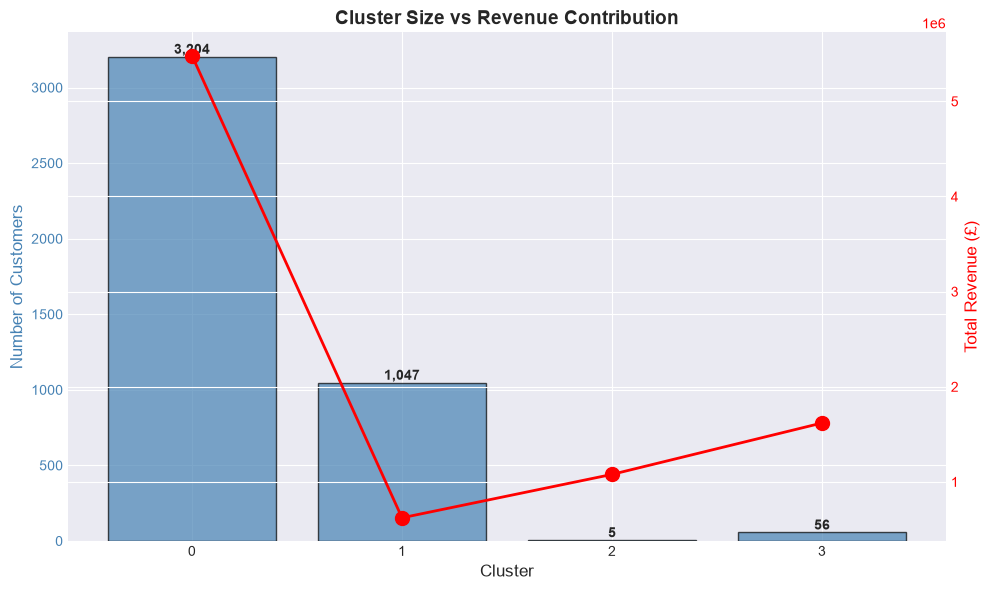

In [13]:
fig, ax1 = plt.subplots(figsize=(10, 6))

clusters = cluster_profile.index.astype(str)
counts = cluster_profile['Count']
revenue = cluster_profile['Total_Revenue']

bars = ax1.bar(clusters, counts, color='steelblue', alpha=0.7, 
               edgecolor='black', label='Customer Count')
ax1.set_xlabel('Cluster', fontsize=12)
ax1.set_ylabel('Number of Customers', color='steelblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')

for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{int(count):,}', ha='center', va='bottom', fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(clusters, revenue, color='red', marker='o', 
         linewidth=2, markersize=10, label='Total Revenue')
ax2.set_ylabel('Total Revenue (£)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Cluster Size vs Revenue Contribution', fontweight='bold', fontsize=14)
fig.tight_layout()
plt.savefig('../reports/figures/kmeans_size_vs_revenue.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
def interpret_clusters(profile: pd.DataFrame) -> dict:
    """
    Assign business labels based on RFM characteristics.
    Lower recency = better, higher freq/monetary = better.
    """
    interpretation = {}
    
    # Rank each cluster (1 = best)
    r_rank = profile['Avg_Recency'].rank()               # low recency = rank 1
    f_rank = profile['Avg_Frequency'].rank(ascending=False)
    m_rank = profile['Avg_Monetary'].rank(ascending=False)
    
    combined_rank = r_rank + f_rank + m_rank
    
    sorted_clusters = combined_rank.sort_values().index.tolist()
    
    labels_pool = ['Champions', 'Loyal Customers', 'At Risk', 'Lost/Low Value']
    
    for i, cluster in enumerate(sorted_clusters):
        label = labels_pool[i] if i < len(labels_pool) else f'Segment {cluster}'
        interpretation[cluster] = label
    
    return interpretation

cluster_labels = interpret_clusters(cluster_profile)

print("Cluster Business Interpretations:\n")
for cluster, label in sorted(cluster_labels.items()):
    row = cluster_profile.loc[cluster]
    print(f"Cluster {cluster} -> {label}")
    print(f"    Recency:   {row['Avg_Recency']:.0f} days")
    print(f"    Frequency: {row['Avg_Frequency']:.1f} orders")
    print(f"    Monetary:  £{row['Avg_Monetary']:.2f}")
    print(f"    Customers: {int(row['Count']):,} | Revenue Share: {row['Revenue_Share_%']:.1f}%\n")

Cluster Business Interpretations:

Cluster 0 -> At Risk
    Recency:   43 days
    Frequency: 4.5 orders
    Monetary:  £1710.65
    Customers: 3,204 | Revenue Share: 62.3%

Cluster 1 -> Lost/Low Value
    Recency:   243 days
    Frequency: 1.7 orders
    Monetary:  £593.54
    Customers: 1,047 | Revenue Share: 7.1%

Cluster 2 -> Champions
    Recency:   6 days
    Frequency: 113.6 orders
    Monetary:  £215535.00
    Customers: 5 | Revenue Share: 12.2%

Cluster 3 -> Loyal Customers
    Recency:   15 days
    Frequency: 47.0 orders
    Monetary:  £28896.42
    Customers: 56 | Revenue Share: 18.4%



In [15]:
customer_clustered['Segment'] = customer_clustered['Cluster'].map(cluster_labels)

print("Final segment distribution:\n")
seg_dist = customer_clustered['Segment'].value_counts()
for seg, count in seg_dist.items():
    pct = (count / len(customer_clustered)) * 100
    print(f"  {seg}: {count:,} ({pct:.1f}%)")

customer_clustered[['Customer ID', 'Recency', 'Frequency', 
                    'Monetary', 'Cluster', 'Segment']].head(10)

Final segment distribution:

  At Risk: 3,204 (74.3%)
  Lost/Low Value: 1,047 (24.3%)
  Loyal Customers: 56 (1.3%)
  Champions: 5 (0.1%)


,Customer ID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.00,165,11,372.86,1,Lost/Low Value
1,12347.00,3,2,1323.32,0,At Risk
2,12348.00,74,1,222.16,0,At Risk
3,12349.00,43,3,2671.14,0,At Risk
4,12351.00,11,1,300.93,0,At Risk
5,12352.00,11,2,343.80,0,At Risk
6,12353.00,44,1,317.76,0,At Risk
7,12355.00,203,1,488.21,1,Lost/Low Value
8,12356.00,16,3,3560.30,0,At Risk
9,12357.00,24,2,12079.99,0,At Risk


In [16]:
Path('../data/processed').mkdir(parents=True, exist_ok=True)
Path('../models').mkdir(parents=True, exist_ok=True)

customer_clustered.to_csv('../data/processed/customer_segments.csv', index=False)
metrics_df.to_csv('../data/processed/kmeans_metrics.csv', index=False)

# Persist the model + scaler for reuse in the app / API
import joblib
joblib.dump(clustering.model, '../models/kmeans_model.pkl')
joblib.dump(clustering.scaler, '../models/scaler.pkl')

print("Saved files:")
print("  - data/processed/customer_segments.csv")
print("  - data/processed/kmeans_metrics.csv")
print("  - models/kmeans_model.pkl")
print("  - models/scaler.pkl")

Saved files:
  - data/processed/customer_segments.csv
  - data/processed/kmeans_metrics.csv
  - models/kmeans_model.pkl
  - models/scaler.pkl


In [17]:
import json

clustering_summary = {
    'analysis_date': pd.Timestamp.now().isoformat(),
    'algorithm': 'KMeans',
    'optimal_k': int(OPTIMAL_K),
    'features_used': feature_cols,
    'total_customers': int(len(customer_clustered)),
    'evaluation_metrics': {
        k: float(v) for k, v in eval_metrics.items() if v is not None
    },
    'optimal_k_recommendations': {
        'silhouette': best_silhouette_k,
        'calinski_harabasz': best_ch_k,
        'davies_bouldin': best_db_k,
    },
    'clusters': {}
}

for cluster in sorted(cluster_labels.keys()):
    row = cluster_profile.loc[cluster]
    clustering_summary['clusters'][str(cluster)] = {
        'label': cluster_labels[cluster],
        'count': int(row['Count']),
        'avg_recency': float(row['Avg_Recency']),
        'avg_frequency': float(row['Avg_Frequency']),
        'avg_monetary': float(row['Avg_Monetary']),
        'total_revenue': float(row['Total_Revenue']),
        'revenue_share_pct': float(row['Revenue_Share_%']),
    }

with open('../reports/clustering_summary.json', 'w') as f:
    json.dump(clustering_summary, f, indent=4)

print("Clustering summary saved to reports/clustering_summary.json")


Clustering summary saved to reports/clustering_summary.json


In [20]:

print("K-MEANS CLUSTERING SUMMARY")


print(f"\nAlgorithm:          K-Means")
print(f"Optimal k:          {OPTIMAL_K}")
print(f"Features:           {', '.join(feature_cols)}")
print(f"Total customers:    {len(customer_clustered):,}")

print(f"\nModel Quality:")
print(f"  Silhouette:       {eval_metrics['silhouette']:.3f}")
print(f"  Calinski-Harabasz:{eval_metrics['calinski_harabasz']:.1f}")
print(f"  Davies-Bouldin:   {eval_metrics['davies_bouldin']:.3f}")

print(f"\nSegments:")
for cluster in sorted(cluster_labels.keys()):
    row = cluster_profile.loc[cluster]
    label = cluster_labels[cluster]
    print(f"  {label:20s} {int(row['Count']):>5,} customers "
          f"({row['Revenue_Share_%']:>5.1f}% revenue)")

print(f"\nFiles Created:")
print(f"  - customer_segments.csv")
print(f"  - kmeans_model.pkl + scaler.pkl")
print(f"  - clustering_summary.json")
print(f"  - 4 visualization plots")


K-MEANS CLUSTERING SUMMARY

Algorithm:          K-Means
Optimal k:          4
Features:           Recency, Frequency, Monetary
Total customers:    4,312

Model Quality:
  Silhouette:       0.611
  Calinski-Harabasz:3742.2
  Davies-Bouldin:   0.616

Segments:
  At Risk              3,204 customers ( 62.3% revenue)
  Lost/Low Value       1,047 customers (  7.1% revenue)
  Champions                5 customers ( 12.2% revenue)
  Loyal Customers         56 customers ( 18.4% revenue)

Files Created:
  - customer_segments.csv
  - kmeans_model.pkl + scaler.pkl
  - clustering_summary.json
  - 4 visualization plots
